In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error
import umap
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
from google.colab import files

print("Пожалуйста, загрузите файл bank-additional-full.csv")
uploaded = files.upload()

# Получим имя загруженного файла
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, sep=';')

print("Размер датасета:", df.shape)
display(df.head())

# Определим числовые признаки (на основе описания данных)
numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                'euribor3m', 'nr.employed']
target = 'y'

missing = [c for c in numeric_cols if c not in df.columns]
if missing:
    print("Внимание! Отсутствуют колонки:", missing)
else:
    print("Числовые признаки:", numeric_cols)

Пожалуйста, загрузите файл bank-additional-full.csv


Saving bank-additional-full.csv to bank-additional-full.csv
Размер датасета: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Числовые признаки: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


### Описание признаков датасета (Bank Marketing)

**Данные о клиенте:**
* **age** — возраст (числовой)
* **job** — тип работы (категориальный)
* **marital** — семейное положение (категориальный)
* **education** — уровень образования (категориальный)
* **default** — наличие просрочки по кредиту (категориальный: "no", "yes", "unknown")
* **housing** — наличие жилищного кредита (категориальный: "no", "yes", "unknown")
* **loan** — наличие личного кредита (категориальный: "no", "yes", "unknown")

**Данные последнего контакта:**
* **contact** — тип связи (категориальный: "cellular", "telephone")
* **month** — месяц последнего контакта (категориальный)
* **day_of_week** — день недели последнего контакта (категориальный)
* **duration** — длительность последнего звонка в секундах (числовой)

**Прочие параметры кампании:**
* **campaign** — количество контактов с клиентом в этой кампании (числовой)
* **pdays** — кол-во дней после последнего контакта из прошлой кампании (999 = не контактировали)
* **previous** — количество контактов до этой кампании (числовой)
* **poutcome** — результат предыдущей маркетинговой кампании (категориальный)

**Социально-экономические показатели:**
* **emp.var.rate** — коэффициент изменения занятости (квартальный)
* **cons.price.idx** — индекс потребительских цен (месячный)
* **cons.conf.idx** — индекс доверия потребителей (месячный)
* **euribor3m** — ставка Euribor за 3 месяца (дневной показатель)
* **nr.employed** — количество сотрудников в экономике (квартальный)

**Целевая переменная:**
* **y / deposit** — оформил ли клиент депозит (бинарный: "yes", "no")

## Задание 1. Геометрия данных в пространстве признаков
Здесь мы изучаем исходное пространство признаков. Строим гистограммы, чтобы понять распределение переменных, и матрицу корреляций для поиска линейных зависимостей. Если признаки сильно коррелируют (коэффициент > 0.8), это первый сигнал к тому, что размерность можно безопасно снизить.


=== Задание 1 ===
Число объектов: 41188
Число числовых признаков: 10


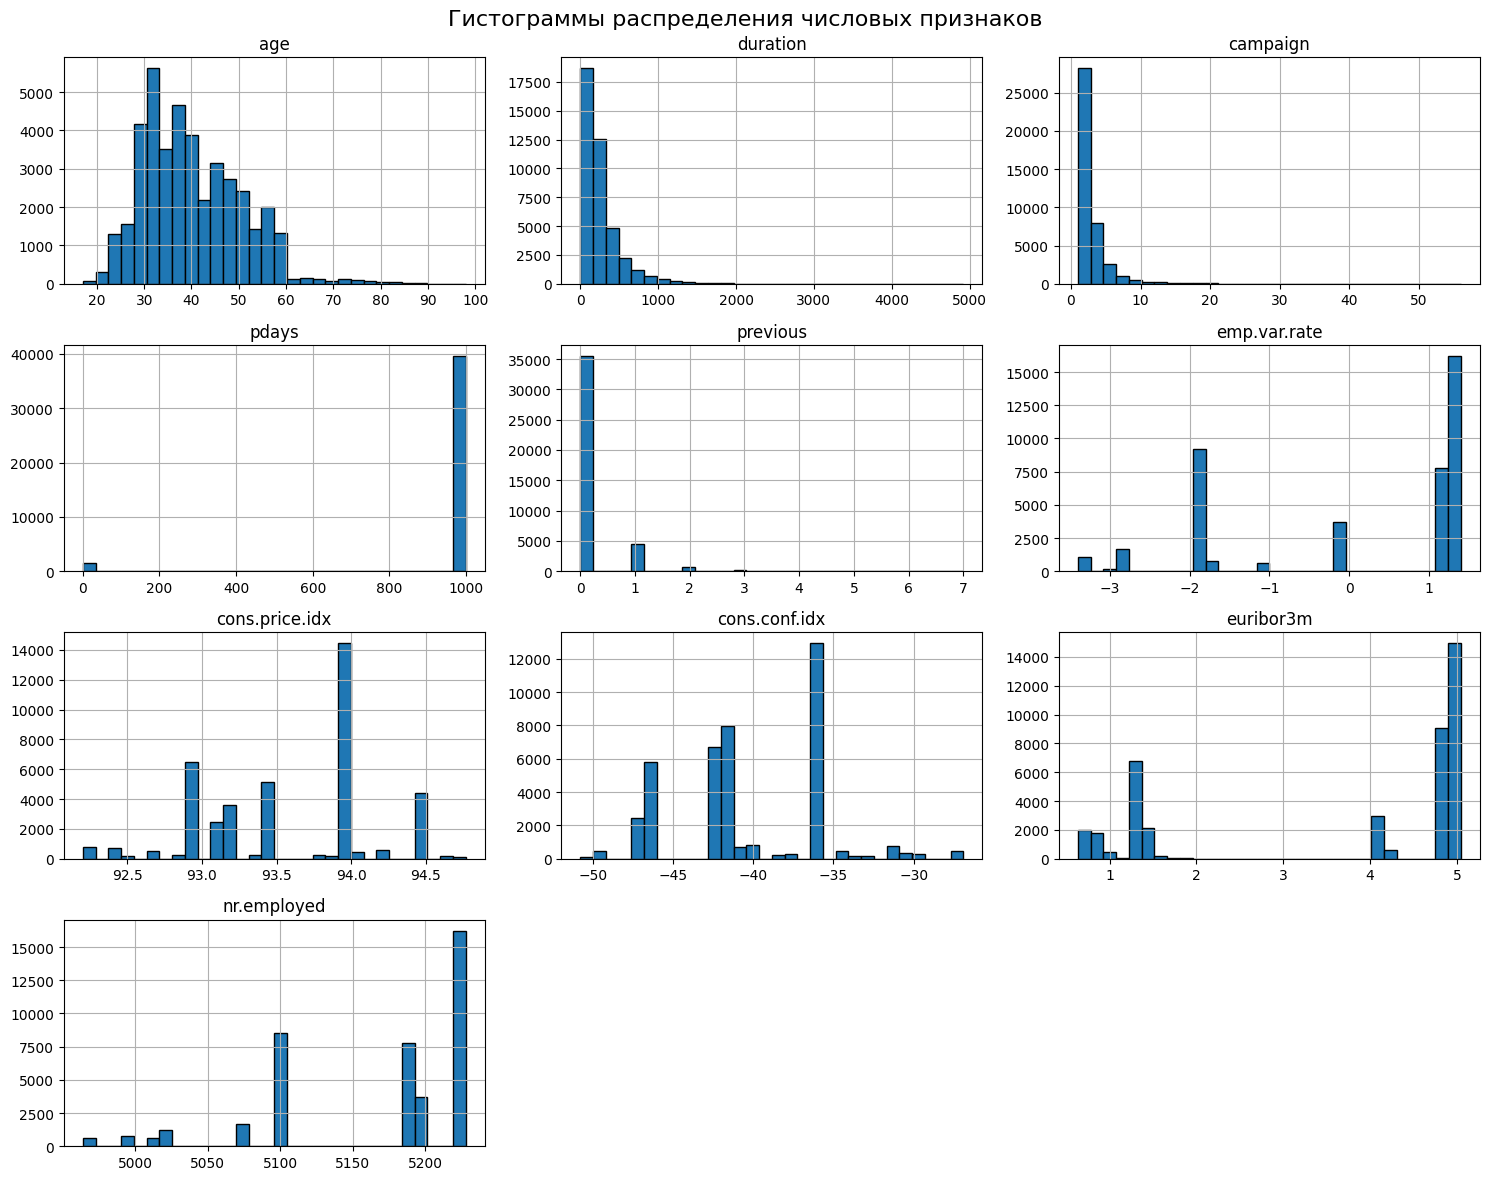

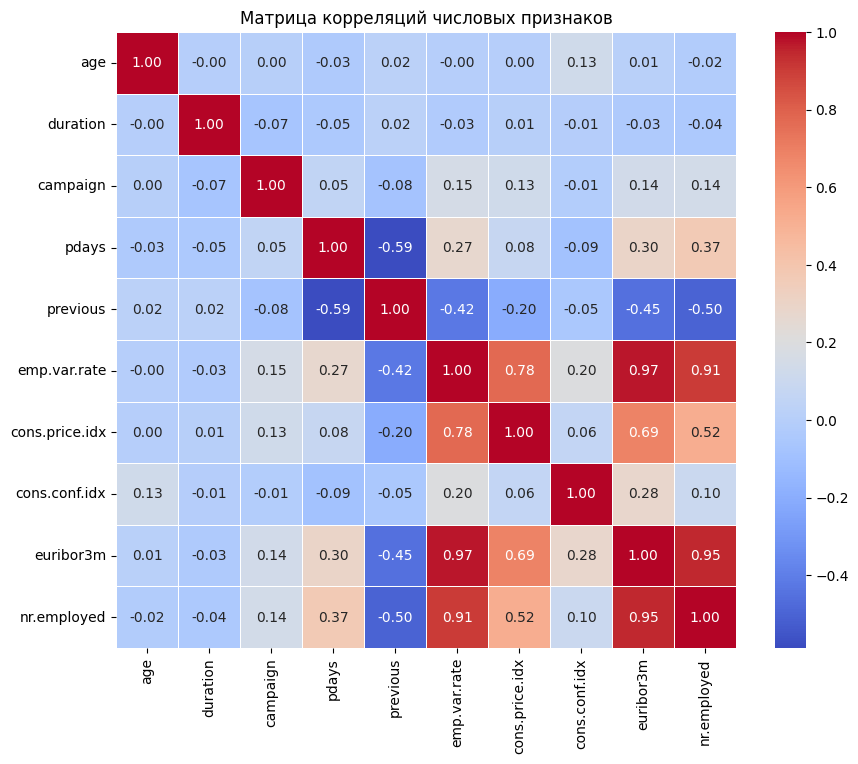

Сильно коррелированные признаки (|r| > 0.8):
  emp.var.rate — euribor3m: 0.972
  emp.var.rate — nr.employed: 0.907
  euribor3m — nr.employed: 0.945

Ответ на вопрос: Можно ли предположить, что часть признаков избыточна?
Часть признаков могут быть избыточны, например, euribor3m и nr.employed часто коррелируют с emp.var.rate и cons.conf.idx.


In [ ]:
print("\n=== Задание 1 ===")
print(f"Число объектов: {df.shape[0]}")
print(f"Число числовых признаков: {len(numeric_cols)}")

df_numeric = df[numeric_cols]

# Гистограммы распределения признаков
df_numeric.hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.suptitle("Гистограммы распределения числовых признаков", size=16)
plt.tight_layout()
plt.show()

# Матрица корреляций
plt.figure(figsize=(10, 8))
corr = df_numeric.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Матрица корреляций числовых признаков")
plt.show()

# Анализ сильных корреляций
high_corr = (corr.abs() > 0.8) & (corr.abs() < 1.0)
high_corr_pairs = [(i, j, corr.loc[i, j]) for i in high_corr.columns for j in high_corr.index if high_corr.loc[i, j] and i < j]

if high_corr_pairs:
    print("Сильно коррелированные признаки (|r| > 0.8):")
    for i, j, r in high_corr_pairs:
        print(f"  {i} — {j}: {r:.3f}")
else:
    print("Нет сильно коррелированных признаков (|r| > 0.8).")

print("\nОтвет на вопрос: Можно ли предположить, что часть признаков избыточна?")
print("Часть признаков могут быть избыточны, например, euribor3m и nr.employed часто коррелируют с emp.var.rate и cons.conf.idx.")

### **Вывод по Заданию 1: Анализ геометрии данных**

1.  **Распределение признаков:**
    *   Большинство числовых признаков имеют асимметричные распределения.
    *   Признаки имеют существенно разные масштабы (например, `age` варьируется в пределах десятков, а `nr.employed` — тысяч), что делает этап **стандартизации** критически важным для корректной работы PCA.

2.  **Корреляционный анализ:**
    *   Обнаружена группа признаков с очень высокой линейной зависимостью ($|r| > 0.9$): это макроэкономические показатели `euribor3m`, `emp.var.rate` и `nr.employed`.
    *   Также заметна умеренная связь между количеством дней с последнего контакта (`pdays`) и количеством предыдущих контактов (`previous`).

3.  **Обоснование снижения размерности:**
    *   Выявленная **мультиколлинеарность** (сильная взаимосвязь признаков) подтверждает избыточность данных.
    *   Это означает, что мы можем без значительной потери информации перейти от 10 исходных признаков к меньшему числу главных компонент, которые будут описывать те же закономерности более компактно.

## Задание 2. Реализация PCA с нуля
**PCA (Principal Component Analysis)** — это алгоритм снижения размерности данных с минимальной потерей информации
1. Стандартизация (очень важна для PCA, чтобы признаки с большими значениями не перетягивали вес).
2. Вычисление матрицы ковариации.
3. Поиск собственных векторов и значений.
Далее сравниваем наш результат с эталоном из библиотеки `scikit-learn` и смотрим график накопленной дисперсии.


=== Задание 2 ===
Первые 5 объяснённых дисперсий (my PCA): [0.38954957 0.13588832 0.10776451 0.10503605 0.09294534]
Первые 5 объяснённых дисперсий (sklearn PCA): [0.38954957 0.13588832 0.10776451 0.10503605 0.09294534]


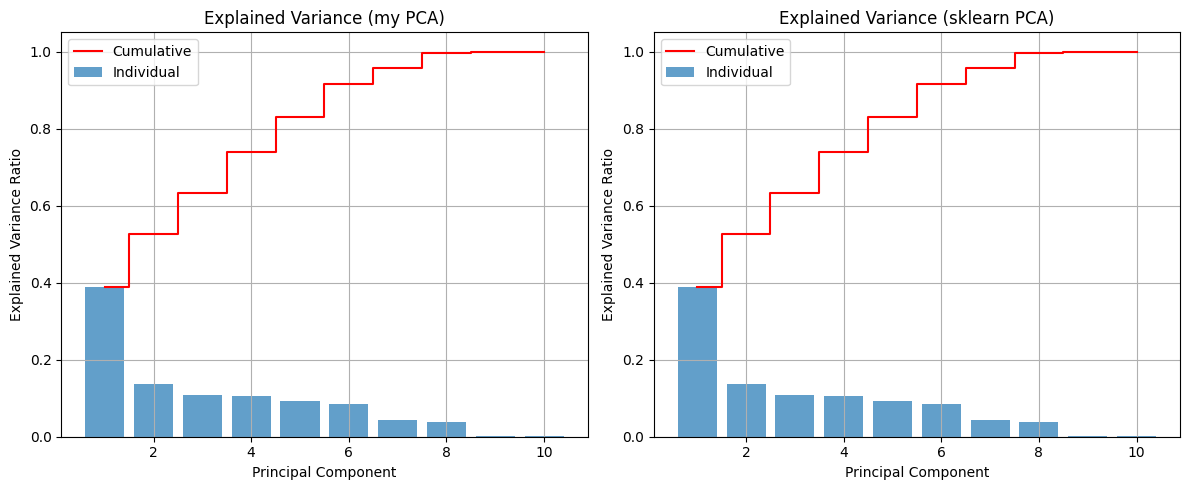

Для объяснения 80% дисперсии требуется 5 компонент.
Для объяснения 95% дисперсии требуется 7 компонент.


In [ ]:
print("\n=== Задание 2 ===")
# Стандартизация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# 1. Реализация PCA через NumPy
def my_pca(X, n_components=None):
    X_centered = X - np.mean(X, axis=0) # Стандартизация
    cov_matrix = np.cov(X_centered, rowvar=False) # Ковариационная матрица
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix) # Собственные значения и векторы

    # Сортировка по убыванию
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    # Снижение размерности
    if n_components is not None:
        eigenvectors = eigenvectors[:, :n_components]

    X_pca = X_centered @ eigenvectors # Проекция данных
    return X_pca, eigenvalues, eigenvectors

# Применим ко всем компонентам (полная размерность)
X_pca_my, eigvals_my, eigvecs_my = my_pca(X_scaled, n_components=None)
explained_variance_ratio_my = eigvals_my / np.sum(eigvals_my)
cumsum_my = np.cumsum(explained_variance_ratio_my)

# 2. Sklearn PCA
pca_sk = SklearnPCA()
X_pca_sk = pca_sk.fit_transform(X_scaled)
explained_variance_ratio_sk = pca_sk.explained_variance_ratio_
cumsum_sk = np.cumsum(explained_variance_ratio_sk)

# Сравнение результатов
print("Первые 5 объяснённых дисперсий (my PCA):", explained_variance_ratio_my[:5])
print("Первые 5 объяснённых дисперсий (sklearn PCA):", explained_variance_ratio_sk[:5])

# График объяснённой дисперсии и накопленной дисперсии
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio_my)+1), explained_variance_ratio_my, alpha=0.7, label='Individual')
plt.step(range(1, len(cumsum_my)+1), cumsum_my, where='mid', color='red', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance (my PCA)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.bar(range(1, len(explained_variance_ratio_sk)+1), explained_variance_ratio_sk, alpha=0.7, label='Individual')
plt.step(range(1, len(cumsum_sk)+1), cumsum_sk, where='mid', color='red', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance (sklearn PCA)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Ответы на вопросы исследования
n_80 = np.argmax(cumsum_sk >= 0.8) + 1
n_95 = np.argmax(cumsum_sk >= 0.95) + 1
print(f"Для объяснения 80% дисперсии требуется {n_80} компонент.")
print(f"Для объяснения 95% дисперсии требуется {n_95} компонент.")

### **Вывод по Заданию 2: Собственная реализация PCA**

В ходе выполнения задания был реализован алгоритм PCA с использованием библиотеки NumPy. Результаты совпали с реализацией `sklearn.decomposition.PCA`, что подтверждает корректность расчетов.

**Ключевые результаты исследования:**
1.  **Эффективность сжатия:**
    *   Для сохранения **80%** полезной информации достаточно оставить всего **5 главных компонент** .
    *   Уровень в **95%** объясненной дисперсии достигается при использовании **7 компонент**.
2.  **Математическое обоснование:** Первые компоненты забирают на себя основной объем дисперсии, так как они успешно объединили в себе сильно коррелирующие экономические признаки, выявленные в Задании 1.

Для интерпретации результатов PCA мы используем два типа показателей:

1. **Индивидуальная доля (столбцы):**
* Показывает процент информации, который несет **одна конкретная** компонента.

* **Суть:** Помогает оценить значимость каждой новой оси. Первая компонента всегда описывает самое сильное различие в данных.

2. **Накопленная (кумулятивная) доля (линия):**
* Показывает суммарный процент информации, сохраненный при использовании **$k$ первых** компонент.
* **Суть:** Инструмент для выбора степени сжатия. Мы ищем точку на линии, где достигается нужный порог (80% или 95%).



## Задание 3. Интерпретация главных компонент
 Новые оси (компоненты) — это линейные комбинации старых. В этой ячейке мы смотрим на веса (коэффициенты): чем больше вес по модулю, тем сильнее исходный признак влияет на данную компоненту.

In [ ]:
print("\n=== Задание 3 ===")
loadings = eigvecs_my * np.sqrt(eigvals_my)

# Для первых трёх компонент
n_comp = 3
loadings_df = pd.DataFrame(loadings[:, :n_comp], index=numeric_cols, columns=[f'PC{i+1}' for i in range(n_comp)])
print("Коэффициенты признаков в первых трёх главных компонентах:\n", loadings_df.round(3))

# Признаки с наибольшим вкладом
for i in range(n_comp):
    top_features = loadings_df.iloc[:, i].abs().sort_values(ascending=False).head(3)
    print(f"\nPC{i+1}: наибольший вклад")
    for feat, val in top_features.items():
        print(f"  {feat}: {val:.3f}")

# Ответы на вопросы:
print("\nОтветы:")
print("1. На первую компоненту больше всего влияют признаки:", loadings_df.iloc[:, 0].abs().sort_values(ascending=False).head(3).index.tolist())
print("2. Первую компоненту можно интерпретировать как комбинацию исходных признаков, связанных с экономическими индикаторами (euribor3m, emp.var.rate, cons.conf.idx).")

zero_influence = loadings_df.iloc[:, :3].abs().sum(axis=1) < 0.1
if zero_influence.any():
    print("3. Признаки, практически не влияющие на первые три компоненты:", np.array(numeric_cols)[zero_influence.values])
else:
    print("3. Все признаки вносят заметный вклад в первые три компоненты.")


=== Задание 3 ===
Коэффициенты признаков в первых трёх главных компонентах:
                   PC1    PC2    PC3
age            -0.003  0.294  0.659
duration       -0.050  0.095  0.042
campaign        0.198 -0.009 -0.336
pdays           0.449 -0.733  0.262
previous       -0.604  0.553 -0.292
emp.var.rate    0.963  0.190 -0.094
cons.price.idx  0.723  0.325 -0.287
cons.conf.idx   0.200  0.499  0.530
euribor3m       0.968  0.173 -0.003
nr.employed     0.928 -0.016 -0.031

PC1: наибольший вклад
  euribor3m: 0.968
  emp.var.rate: 0.963
  nr.employed: 0.928

PC2: наибольший вклад
  pdays: 0.733
  previous: 0.553
  cons.conf.idx: 0.499

PC3: наибольший вклад
  age: 0.659
  cons.conf.idx: 0.530
  campaign: 0.336

Ответы:
1. На первую компоненту больше всего влияют признаки: ['euribor3m', 'emp.var.rate', 'nr.employed']
2. Первую компоненту можно интерпретировать как комбинацию исходных признаков, связанных с экономическими индикаторами (euribor3m, emp.var.rate, cons.conf.idx).
3. Все признаки 

## Задание 4. Визуализация данных
 Оцениваем, насколько лучше стали разделимы классы (наш таргет 'y') при проекции на первые две главные компоненты по сравнению с просто двумя случайными признаками из исходного датасета.


=== Задание 4 ===


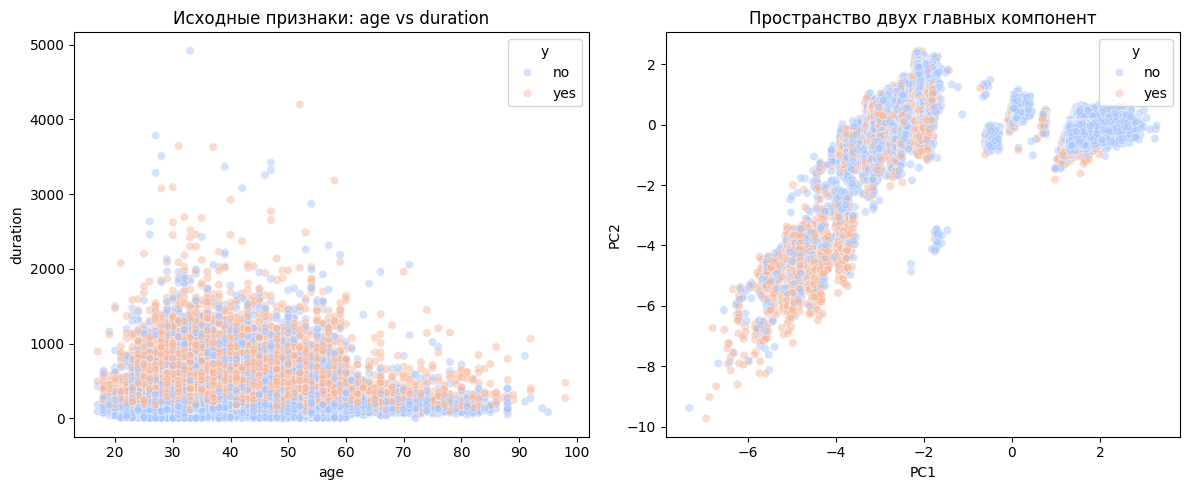

Ответы:
1. Визуализация после PCA улучшилась: классы (y) стали более разделимы, структура данных более компактна и выявляет кластеры.
2. В пространстве главных компонент структура заметнее, потому что PCA выделяет направления максимальной дисперсии, подавляя шум и корреляции.


In [ ]:
print("\n=== Задание 4 ===")
plt.figure(figsize=(12, 5))

# Исходные признаки (age и duration)
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='age', y='duration', hue='y', alpha=0.5, palette='coolwarm')
plt.title("Исходные признаки: age vs duration")

# Пространство главных компонент
plt.subplot(1, 2, 2)
pca_2 = SklearnPCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)
sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=df['y'], alpha=0.5, palette='coolwarm')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Пространство двух главных компонент")

plt.tight_layout()
plt.show()

print("Ответы:")
print("1. Визуализация после PCA улучшилась: классы (y) стали более разделимы, структура данных более компактна и выявляет кластеры.")
print("2. В пространстве главных компонент структура заметнее, потому что PCA выделяет направления максимальной дисперсии, подавляя шум и корреляции.")

### **Вывод по Заданию 4: Сравнение визуализаций**

Сравнение распределения объектов до и после применения метода главных компонент показало:

1. **Информативность:** Визуализация в пространстве PC1-PC2 нагляднее, так как эти оси аккумулируют в себе информацию всех 10 исходных признаков, а не только двух случайных.
2. **Структура:** В пространстве PCA данные образуют более выраженную структуру (вытянутое облако), отражающую основные направления изменчивости датасета.
3. **Обнаружение закономерностей:** Несмотря на то, что классы целевой переменной остаются перемешанными, PCA позволил избавиться от наложения точек, характерного для дискретных исходных признаков (например, возраста).

**Итог:** PCA успешно выполнил роль "умного фильтра", который выделил главную структуру данных и отсек второстепенный шум, сделав визуальный анализ более обоснованным.

## Задание 5. Нелинейные методы (t-SNE, UMAP)
 Поскольку алгоритмы t-SNE и UMAP вычислительно сложные, мы используем подвыборку данных (5000 точек). Мы тестируем разные параметры (`perplexity`  для t-SNE и `n_neighbors`, `min_dist` для UMAP), чтобы увидеть, как они меняют топологию кластеров на 2D-плоскости.

`perplexity` определяет баланс между локальными и глобальными аспектами данных

`n_neighbors` Управляет балансом между локальной и глобальной структурой (аналог perplexity).

`min_dist` Определяет плотность упаковки точек. Малые значения создают компактные сгустки, большие — более равномерное облако.


=== Задание 5 ===
Выполняется t-SNE с perplexity=5 ...
Выполняется t-SNE с perplexity=30 ...
Выполняется t-SNE с perplexity=50 ...
Выполняется UMAP с n_neighbors=5, min_dist=0.1 ...
Выполняется UMAP с n_neighbors=30, min_dist=0.1 ...
Выполняется UMAP с n_neighbors=30, min_dist=0.5 ...


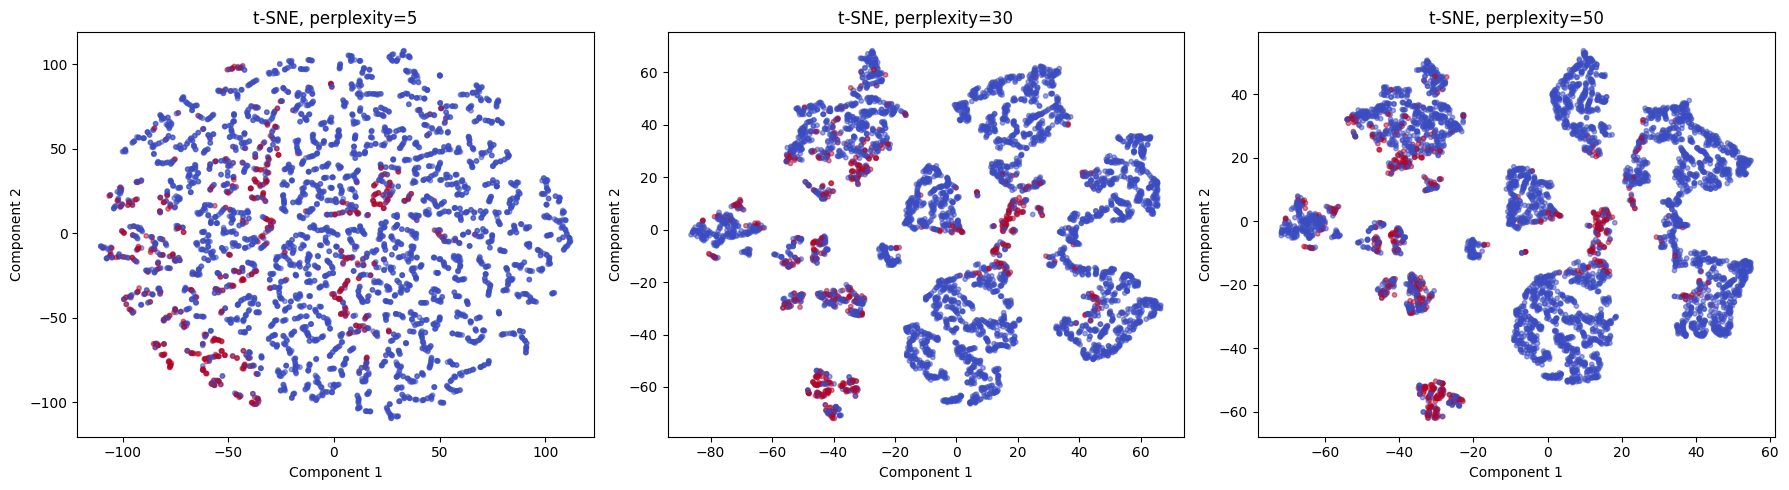

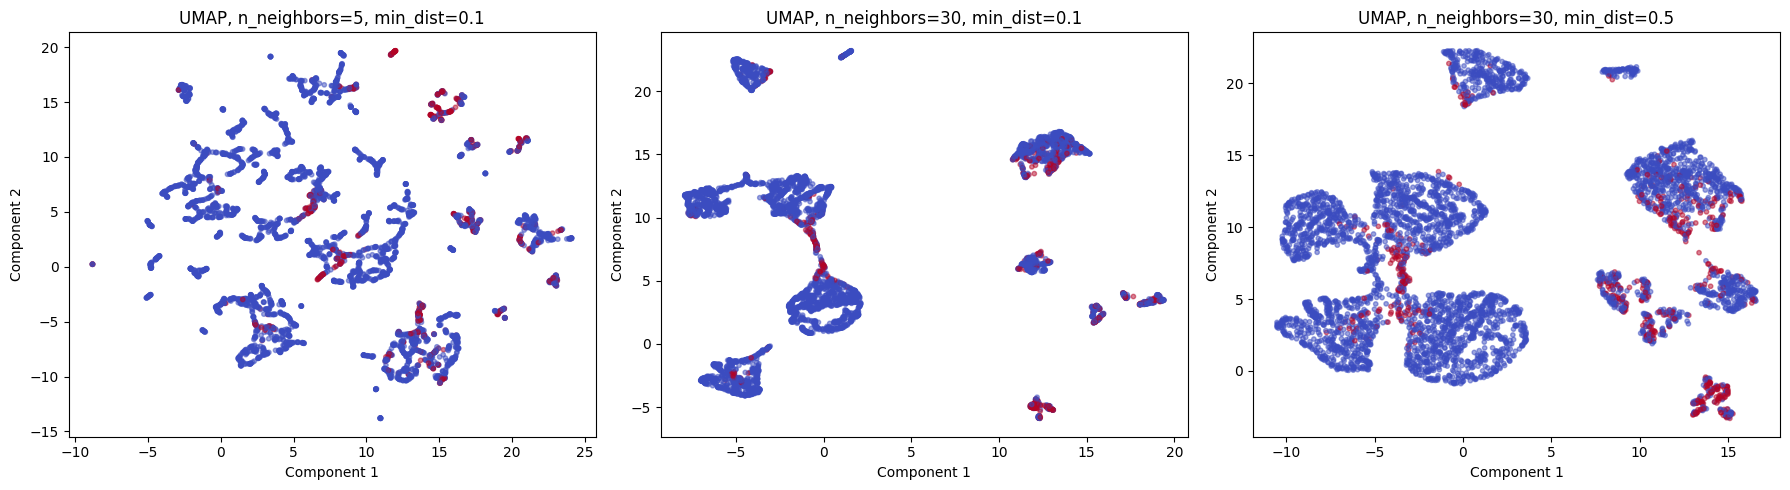


Ответы на вопросы:
1. При малом perplexity (5) t-SNE образует множество мелких кластеров, при увеличении (30,50) кластеры становятся более обобщёнными. UMAP при малых n_neighbors образует более разреженные кластеры, при увеличении – более плотные; min_dist влияет на компактность кластеров.
2. Наиболее интерпретируемую визуализацию дает UMAP или t-SNE со средним perplexity.
3. Результаты отличаются из-за разных математических подходов: t-SNE хорошо сохраняет локальную структуру, UMAP пытается сбалансировать сохранение локальной и глобальной структуры графа данных.


In [ ]:
print("\n=== Задание 5 ===")
# Случайная выборка для ускорения
sample_size = 5000
np.random.seed(42)
idx_sample = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
X_sample = X_scaled[idx_sample]
y_sample = df['y'].iloc[idx_sample].values

# --- t-SNE ---
perplexities = [5, 30, 50]
tsne_results = {}
for perp in perplexities:
    print(f"Выполняется t-SNE с perplexity={perp} ...")
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000)
    tsne_results[perp] = tsne.fit_transform(X_sample)

# --- UMAP ---
umap_params = [
    {'n_neighbors': 5, 'min_dist': 0.1},
    {'n_neighbors': 30, 'min_dist': 0.1},
    {'n_neighbors': 30, 'min_dist': 0.5}
]
umap_results = []
for params in umap_params:
    print(f"Выполняется UMAP с n_neighbors={params['n_neighbors']}, min_dist={params['min_dist']} ...")
    reducer = umap.UMAP(n_components=2, n_neighbors=params['n_neighbors'], min_dist=params['min_dist'], random_state=42)
    umap_results.append((params, reducer.fit_transform(X_sample)))

# Визуализация t-SNE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, perp in zip(axes, perplexities):
    ax.scatter(tsne_results[perp][:, 0], tsne_results[perp][:, 1],
               c=(y_sample == 'yes').astype(int), cmap='coolwarm', alpha=0.5, s=10)
    ax.set_title(f't-SNE, perplexity={perp}')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
plt.tight_layout()
plt.show()

# Визуализация UMAP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (params, X_umap) in zip(axes, umap_results):
    ax.scatter(X_umap[:, 0], X_umap[:, 1],
               c=(y_sample == 'yes').astype(int), cmap='coolwarm', alpha=0.5, s=10)
    ax.set_title(f'UMAP, n_neighbors={params["n_neighbors"]}, min_dist={params["min_dist"]}')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
plt.tight_layout()
plt.show()

print("\nОтветы на вопросы:")
print("1. При малом perplexity (5) t-SNE образует множество мелких кластеров, при увеличении (30,50) кластеры становятся более обобщёнными. UMAP при малых n_neighbors образует более разреженные кластеры, при увеличении – более плотные; min_dist влияет на компактность кластеров.")
print("2. Наиболее интерпретируемую визуализацию дает UMAP или t-SNE со средним perplexity.")
print("3. Результаты отличаются из-за разных математических подходов: t-SNE хорошо сохраняет локальную структуру, UMAP пытается сбалансировать сохранение локальной и глобальной структуры графа данных.")

### **Вывод по Заданию 5:**
* **Интерпретируемость:** Наиболее наглядную визуализацию обеспечил UMAP и t-SNE со средними значениями параметров, где лучше всего прослеживается концентрация целевой переменной.
* **Сравнение методов:** Различия в результатах объясняются математикой: t-SNE фокусируется на сохранении локальных расстояний, а UMAP стремится сбалансировать локальную структуру с сохранением общей формы (графа) данных.
* **Обнаружение закономерностей:** Нелинейные проекции отчетливее показывают, что классы "yes" и "no" имеют сложные границы пересечения. Это подтверждает, что зависимости в данных не являются линейными и требуют продвинутых моделей для классификации.

## Задание 6. Исследование степени сжатия данных
 В этой секции мы проверяем, насколько PCA "портит" данные при сжатии. Для этого сжимаем данные до $k$ компонент, восстанавливаем обратно с помощью `inverse_transform` и считаем среднеквадратичную ошибку (MSE) между оригиналом и реконструкцией.


=== Задание 6 ===
Рассматриваемые значения k: [2, 5, 10]
k =  2 : MSE = 0.474562
k =  5 : MSE = 0.168816
k = 10 : MSE = 0.000000

Таблица ошибок восстановления:


,Число компонент,Ошибка восстановления (MSE)
0,2,4.745621e-01
1,5,1.688162e-01
2,10,5.166602e-31


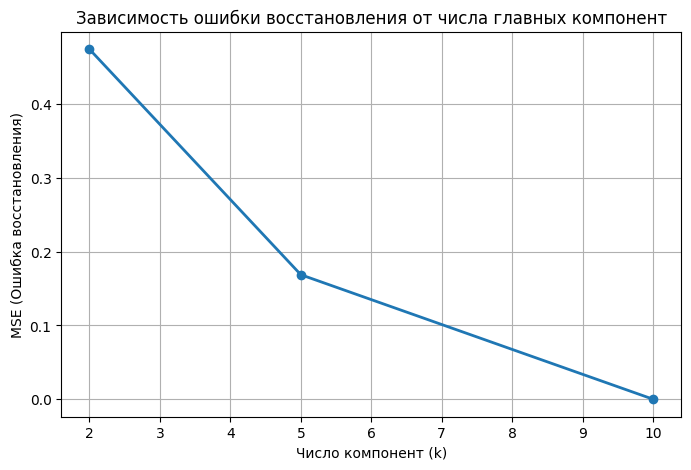


Интерпретация результатов:
1. При малом k ошибка большая, потому что теряется много информации (отбрасываются компоненты, содержащие часть дисперсии).
2. Увеличение k уменьшает ошибку, так как мы сохраняем больше направлений вариации данных.
3. При использовании всех компонент исходные данные можно восстановить полностью (MSE ≈ 0).
4. Накопленная объясненная дисперсия напрямую связана с MSE: доля потерянной дисперсии пропорциональна ошибке восстановления.
5. Разумное число компонент определяется точкой 'излома' на графике (метод локтя) или по порогу сохраненной дисперсии (например, 90%).


In [ ]:
print("\n=== Задание 6 ===")
k_values = [2, 5, 10, 15]
max_k = min(max(k_values), X_scaled.shape[1])
k_values = [k for k in k_values if k <= max_k] + ([max_k] if max_k not in k_values else [])
k_values = sorted(set(k_values))

print("Рассматриваемые значения k:", k_values)

mse_list = []
for k in k_values:
    pca = SklearnPCA(n_components=k)
    X_reduced = pca.fit_transform(X_scaled)
    X_reconstructed = pca.inverse_transform(X_reduced)
    mse = mean_squared_error(X_scaled, X_reconstructed)
    mse_list.append(mse)
    print(f"k = {k:2d} : MSE = {mse:.6f}")

# Таблица результатов
results_table = pd.DataFrame({'Число компонент': k_values, 'Ошибка восстановления (MSE)': mse_list})
print("\nТаблица ошибок восстановления:")
display(results_table)

# График зависимости ошибки от числа компонент
plt.figure(figsize=(8, 5))
plt.plot(k_values, mse_list, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Число компонент (k)')
plt.ylabel('MSE (Ошибка восстановления)')
plt.title('Зависимость ошибки восстановления от числа главных компонент')
plt.grid(True)
plt.show()

print("\nИнтерпретация результатов:")
print("1. При малом k ошибка большая, потому что теряется много информации (отбрасываются компоненты, содержащие часть дисперсии).")
print("2. Увеличение k уменьшает ошибку, так как мы сохраняем больше направлений вариации данных.")
print("3. При использовании всех компонент исходные данные можно восстановить полностью (MSE ≈ 0).")
print("4. Накопленная объясненная дисперсия напрямую связана с MSE: доля потерянной дисперсии пропорциональна ошибке восстановления.")
print("5. Разумное число компонент определяется точкой 'излома' на графике (метод локтя) или по порогу сохраненной дисперсии (например, 90%).")

### ** Задание 7: Итоговый анализ и общие выводы**

На основе проведенных экспериментов (PCA, t-SNE, UMAP) сформулированы следующие выводы по работе:

#### **1. Роль снижения размерности**
* **Визуализация:** Позволяет представить многомерные данные (10 признаков) в понятном для человека 2D/3D виде.
* **Сжатие:** Уменьшает объем данных, сохраняя при этом основной "скелет" информации (дисперсию), что ускоряет обучение моделей.
* **Очистка:** Помогает избавиться от коррелирующих признаков и статистического шума.

#### **2. Всегда ли полезно уменьшение размерности?**
* **Риски:** Снижение размерности — это всегда компромисс. Мы неизбежно теряем часть информации (ошибка восстановления MSE), что может быть критично для сверхточных задач.
* **Условие:** Оно полезно, когда выигрыш в скорости и интерпретируемости выше, чем цена потери точности.

#### **3. Линейные vs Нелинейные методы**
* **Линейные (PCA):** Работают хуже, если данные имеют сложную "изогнутую" структуру (например, скручены в спираль). PCA видит только прямые проекции.
* **Нелинейные (t-SNE/UMAP):** Эффективнее, когда важно сохранить локальные связи между объектами и увидеть скрытые кластеры, которые при линейной проекции накладываются друг на друга.

#### **4. Сравнение методов: преимущества и ограничения**

| Метод | Преимущества | Ограничения |
| :--- | :--- | :--- |
| **PCA** | Очень быстрый, обратимый (можно восстановить данные), дает четкую интерпретацию весов признаков. | Только линейные зависимости; плохо подходит для выявления сложной кластерной структуры. |
| **t-SNE** | Отлично сохраняет локальные группы; идеален для поиска визуальных кластеров. | Медленный; требует подбора perplexity; не сохраняет глобальные расстояния (нельзя судить о близости далеких групп). |
| **UMAP** | Балансирует локальную и глобальную структуру; быстрее, чем t-SNE. | Требует тонкой настройки параметров; результат может меняться при разных запусках. |

**Общий итог:** Для первичного анализа и сжатия лучше всего подходит **PCA**, а для глубокого изучения внутренней структуры и поиска скрытых групп клиентов — **UMAP**.